In [1]:
from datasets import load_dataset_builder, get_dataset_split_names, load_dataset, Dataset, load_from_disk

import torch
import torch.nn as nn
import torch.optim as optim
from transformers import BertTokenizer, BertModel
from sklearn.metrics import roc_curve, auc
from torch.utils.data import DataLoader, TensorDataset, Dataset, random_split
from sklearn.utils import shuffle
from sklearn.metrics import f1_score, roc_auc_score
import random
import pickle
import sys
import os
import argparse

import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

import os, sys

module_path = '/panfs/jay/groups/3/dingj/wang9019/projects/MP'
if module_path not in sys.path:
    sys.path.append(module_path)
    
from util import *
import tweetnlp

/home/dingj/wang9019/anaconda3/envs/dl/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-06-23 22:33:54,780	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2024-06-23 22:33:55,758	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
def paste(x, y, decimal=2):
    """Utility function to print `x (y)` with specified decimal digits."""
    return f'{np.round(x, decimals=decimal)} ({np.round(y, decimals=decimal)})'


In [3]:
dataset_name = 'ToxicCommentChallenge' # ToxicCommentChallenge, hate_speech_offensive
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tag = ''
reg = '' #'_reg'
balance = '_balance' #_balance
model_name = 'bert-base-uncased' #'sentence-transformers/all-MiniLM-L6-v2' 'bert-base-uncased'
support_CLS = False
batch_size = 160
filename = f'embed_{model_name.replace("/", "_")}_{"CLS" if support_CLS else "Avg"}'
train_data_path = f'./benchmark/{dataset_name}/{filename}.pkl'
model_path = f"pretrained/{dataset_name}/{filename.replace('/', '_')}_{tag}{reg}{balance}.pth"
directory =f'pretrained/{dataset_name}'
if not os.path.exists(directory):
    os.makedirs(directory)

# read embedding features
with open(train_data_path, "rb") as input_file:
    X = pickle.load(input_file)['feature'].to_numpy()

# read original dataset 
excel_file_path = f"rawdata/{dataset_name}.csv"
data = pd.read_csv(excel_file_path)

# each raw of X is a vector
X = np.vstack(X)
y = data['normal'].to_numpy()

In [4]:
if tag:
    indice = (data[tag] == 1) | (data['normal'] == 1)
    X, y = X[indice,:], y[indice]
    
if balance:
    min_data_size = min(sum(y == 0), sum(y == 1))
    indices_hate = np.nonzero(y == 0)[0]
    np.random.shuffle(indices_hate)
    indices_normal = np.nonzero(y == 1)[0]
    np.random.shuffle(indices_normal)
    indices = np.concatenate([indices_hate[:min_data_size], indices_normal[:min_data_size]])
    X, y = X[indices, :], y[indices]

full_dataset = TensorDataset(torch.tensor(X), torch.tensor(y))

n_tot = len(full_dataset)
train_size = int(0.4 * n_tot)
val_size = int(0.3 * n_tot)
test_size = n_tot - train_size - val_size

ind = shuffle(list(range(n_tot)))
train_ind = ind[:train_size]
val_ind = ind[train_size:train_size+val_size]
test_ind = ind[train_size+val_size:]

train_dataset = TensorDataset(torch.tensor(X[train_ind]), torch.tensor(y[train_ind]))
val_dataset = TensorDataset(torch.tensor(X[val_ind]), torch.tensor(y[val_ind]))
test_dataset = TensorDataset(torch.tensor(X[test_ind]), torch.tensor(y[test_ind]))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [5]:
test_crit = ZeroOneLoss

In [6]:
teacher = BinaryRegressor(X.shape[1], 256).to(device) if reg else BinaryClassifier(X.shape[1], 256).to(device) 
teacher.load_state_dict(torch.load(model_path, map_location=device))
f'Teacher test error: {test(teacher, test_loader, device=device, criterion=test_crit):.4f}'

'Teacher test error: 0.0981'

In [16]:
directory = f'./benchmark/{dataset_name}'
model_name = 'twitter-roberta-base-hate-latest'
with open(f'{directory}/pred_{model_name.replace("/", "_")}.pkl', 'rb') as f:
    pred_prob = pickle.load(f)['feature']

In [7]:
def avg(un):
    un = un.to_numpy()
    un_cal = np.zeros_like(un)+un

    i = 0
    for j in range(21):
        un_cal[(i+j):(i+j+1260):21] = np.mean(un_cal[(i+j):(i+j+1260):21])

    return un_cal

In [8]:
df = pd.read_csv('./result/steal_ToxicCommentChallenge_bert-base-uncased_balance_test_balance_atk_balance.csv')
print(df[df['defense'] == 'Any'])
res = df[df['defense'] == 'Any'].iloc[0, 4:7].to_numpy()
df = df.loc[df['defense'] != 'Any',:]
df['un'] = avg(df['un'])
df

             query dataset  query size defense   un       acc   f1  auc  \
0    ToxicCommentChallenge           0     Any  0.0  0.494402  0.0  0.5   
631  hate_speech_offensive           0     Any  0.0  0.506317  0.0  0.5   

     train size  
0             0  
631           0  


,query dataset,query size,defense,un,acc,f1,auc,train size
1,ToxicCommentChallenge,1000,No,0.000000,0.823626,0.836989,0.909925,388
2,ToxicCommentChallenge,1000,IID,0.010000,0.831125,0.838284,0.910789,388
3,ToxicCommentChallenge,1000,IID,0.020000,0.835234,0.842312,0.912445,388
4,ToxicCommentChallenge,1000,IID,0.050000,0.817565,0.833583,0.908751,388
5,ToxicCommentChallenge,1000,IID,0.100000,0.821674,0.833173,0.905413,388
...,...,...,...,...,...,...,...,...
1257,hate_speech_offensive,5000,Const,0.012833,0.779456,0.782229,0.857837,1500
1258,hate_speech_offensive,5000,Const,0.021833,0.783256,0.779979,0.861155,1500
1259,hate_speech_offensive,5000,Const,0.056333,0.770827,0.739704,0.864197,1500
1260,hate_speech_offensive,5000,Const,0.114333,0.607191,0.348108,0.872460,1500


In [195]:
defenses = ['No', 'IID', 'DP', 'AM', 'Const']
ns = [1000, 2000, 5000]
row_index = pd.MultiIndex.from_product([defenses, ['acc', 'F1']], names=["defense", "metric"])
col_index = pd.MultiIndex.from_product([ns, [0.01, 0.02, 0.05, 0.1, 0.15]], names = ["query size", '$u_n$'])
res = pd.DataFrame(0, columns=col_index, index=row_index)
data_name = 'hate_speech_offensive'  # 'ToxicCommentChallenge' 'hate_speech_offensive'
for size in ns:
    for d in defenses:
            # res.loc[d, size] = res.loc[d, size].to_numpy(dtype=float)+np.round(df_mean.loc[(data_name, size, d)].T.to_numpy(), decimals=2)
        mean = res.loc[d, size].to_numpy(dtype=float)+df_mean.loc[(data_name, size, d)].T.to_numpy()
        std = res.loc[d, size].to_numpy(dtype=float)+df_std.loc[(data_name, size, d)].T.to_numpy()
        res.loc[d, size] =  paste(mean, std)

In [68]:
un = df['un'].to_numpy()

In [9]:
class BaseClassifier(nn.Module):
    def __init__(self, val):
        super(BaseClassifier, self).__init__()
        self.val = val

    def forward(self, x):
        return self.val*torch.ones(x.shape[0])

def score(clf, x, y_true, device='cpu'):
    y_pred = clf(x.to(device)).detach().cpu().squeeze()
    acc = 1-ZeroOneLoss(y_pred, y_true).item()
    f1 = f1_score(y_true, y_pred>0.5)
    auc = roc_auc_score(y_true, y_pred)
    return acc, f1, auc

In [37]:
X_test = torch.tensor(X[test_ind])
y_test = torch.tensor(y[test_ind])

val = 1 if (sum(y == 1) > sum(y == 0)) else 0
res = score(BaseClassifier(val), X_test, y_test, device=device)
# df[i] = [query_dataset_name, 0, 'Any', 0, *res]

res

(0.4993323087692261, 0.0, 0.5)

In [10]:
X_test = torch.tensor(X[test_ind])
y_test = torch.tensor(y[test_ind])

t_res = score(teacher, X_test, y_test, device=device)
# df[i] = [query_dataset_name, 0, 'Any', 0, *res]

t_res

(0.9019003584980965, 0.9011284812092349, 0.9672413199283683)

In [40]:
y_res = teacher(torch.Tensor(X[val_ind, :]).to(device)).detach().cpu().squeeze()

In [15]:
from _plot_cfg import *

In [23]:
defenses = df['defense'].unique()
palette = sns.color_palette("tab10", len(defenses))
markers = ['o', 'P', 's', 'D', '^', 'X'][:len(defenses)]
line_types = ['', (2, 1),  (2, 2), '','', (2, 3), '', (2, 4)][:len(defenses)]

# markers = ['X', '.', '^', 's', 'o']
name_dic = {'No': 'No defense', 'Const': 'Misleading Shift (Ours)', 'IID': 'Random Shuffle', 
            'DP': 'Deceptive Perturbation', 'AM': 'Adaptive Misinformation'}

df['defense'] = df['defense'].map(lambda x: name_dic[x] if x in name_dic.keys() else x)

In [12]:
df.loc[df['defense']=='No defense', 'un'] = -0.003

In [16]:
import scienceplots
plt.style.use(['science','no-latex'])
# palette = sns.color_palette("tab10", len(defenses))

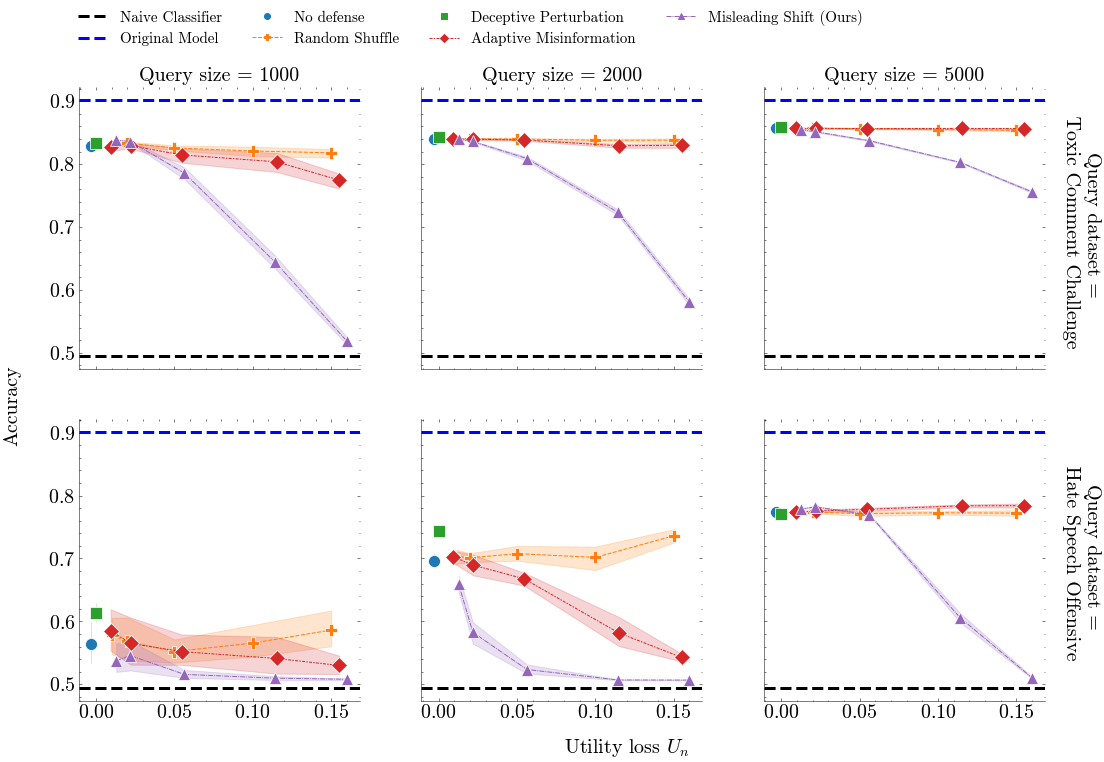

In [25]:
g = sns.relplot(
    data=df, x="un", y="acc", style='defense', markers=markers, markersize=12, legend=True, palette=palette,
    hue="defense", kind='line', col='query size', row='query dataset', facet_kws={'sharey': False, 'sharex': True}
) 

handles, labels = g.axes.ravel()[0].get_legend_handles_labels()
g.legend.set_visible(False)

for ax in g.axes.flatten():
    l1 = ax.axhline(res[0], ls='--', linewidth=3, color='black', label='Naive Classifier')
    l2 = ax.axhline(t_res[0], ls='--', linewidth=3, color='blue', label='Original Model')
    ax.set_xlabel('')
    if not ax.get_subplotspec().is_first_col():
        ax.set_yticklabels('')

handles[0].set_linestyle("")
handles[2].set_linestyle("")
new_handles = [l1, l2]+handles
new_labels = ['Naive Classifier', 'Original Model']+labels
# new_handles = handles
# new_labels = [r'$\bf{Defense:}$']+labels

# g.set_titles(template = 'query size={col_name}')
g.set_titles(template='')

for ax,m in zip(g.axes[0,:],df['query size'].unique()):
    ax.set_title(f'Query size = {m}')
for ax,l in zip(g.axes[:,0],['Toxic Comment Challenge', 'Hate Speech Offensive']):
    ax.set_ylabel('')
for ax,l in zip(g.axes[:,2],['Toxic Comment Challenge', 'Hate Speech Offensive']):
    ax.yaxis.set_label_position("right")
    ax.yaxis.set_label_coords(1.2, 0.5)  
    ax.set_ylabel(f'Query dataset = \n {l}', rotation=270, )
g.fig.supxlabel(r'Utility loss $U_n$')
g.fig.supylabel('Accuracy')

# g.axes[0,-1].legend(new_handles, new_labels, title='', loc = 'lower right')
leg = plt.legend(new_handles, new_labels, title='', bbox_to_anchor=(0.4, 2.5), ncol=4)
leg._legend_box.align = "left"
# leg.get_title().set_position((-1.8, 2.4))
# plt.tight_layout()
plt.savefig('./figures/nlp_tx_acc.pdf')

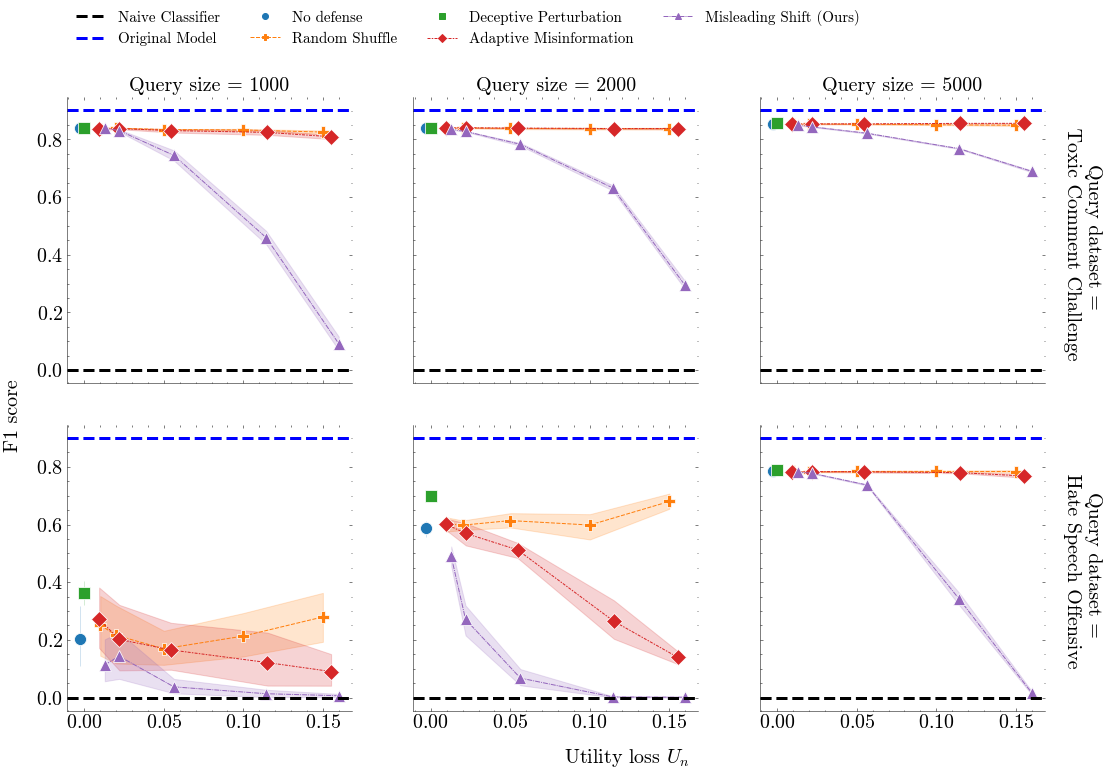

In [26]:
g = sns.relplot(
    data=df, x="un", y="f1", style='defense', markers=markers, markersize=12, palette=palette,
    hue="defense", kind='line', col='query size', row='query dataset', facet_kws={'sharey': False, 'sharex': True}
)
handles, labels = g.axes.ravel()[0].get_legend_handles_labels()
g.legend.set_visible(False)

for ax in g.axes.flatten():
    l1 = ax.axhline(res[1], ls='--', linewidth=3, color='black', label='Naive Classifier')
    l2 = ax.axhline(t_res[1], ls='--', linewidth=3, color='blue', label='Original Model')
    ax.set_xlabel('')
    if not ax.get_subplotspec().is_first_col():
        ax.set_yticklabels('')

handles[0].set_linestyle("")
handles[2].set_linestyle("")
new_handles = [l1, l2]+handles
new_labels = ['Naive Classifier', 'Original Model']+labels

# g.set_titles(template = 'query size={col_name}')
g.set_titles(template='')

for ax,m in zip(g.axes[0,:],df['query size'].unique()):
    ax.set_title(f'Query size = {m}')
for ax,l in zip(g.axes[:,0],['Toxic Comment Challenge', 'Hate Speech Offensive']):
    ax.set_ylabel('')
for ax,l in zip(g.axes[:,2],['Toxic Comment Challenge', 'Hate Speech Offensive']):
    ax.yaxis.set_label_position("right")
    ax.yaxis.set_label_coords(1.2, 0.5)  
    ax.set_ylabel(f'Query dataset = \n {l}', rotation=270, )
g.fig.supxlabel(r'Utility loss $U_n$')
g.fig.supylabel('F1 score')

leg = plt.legend(new_handles, new_labels, title='', bbox_to_anchor=(0.4, 2.5), ncol=4)
leg._legend_box.align = "left"
# g.axes[0,-1].legend(new_handles, new_labels, title='', loc = 'lower right')
# plt.tight_layout()
plt.savefig('./figures/nlp_tx_f1.pdf')